# Connect to google account

In [1]:
from google.colab import drive
drive.mount('/content/data')

Mounted at /content/data


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Global Variables

In [1]:
import os
import numpy as np
import pandas as pd
import random
import torch


def reset_seeds(seed=42):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)    # 파이썬 환경변수 시드 고정
  np.random.seed(seed)
  torch.manual_seed(seed) # cpu 연산 무작위 고정
  torch.cuda.manual_seed(seed) # gpu 연산 무작위 고정
  torch.backends.cudnn.deterministic = True  # cuda 라이브러리에서 Deterministic(결정론적)으로 예측하기 (예측에 대한 불확실성 제거 )


# Load Netflix Data

In [2]:
reset_seeds() # 랜덤고정

import easydict
args = easydict.EasyDict()
from sklearn.model_selection import train_test_split


# 1. 경로 및 파일 설정 (Args 클래스)
class Args:
    def __init__(self):
        self.default_path = 'C:/dev/project/SKN27-2nd-2TEAM/models/data/'

        # 넷플릭스 원본 데이터
        self.users_csv = self.default_path + 'users.csv'
        self.watch_csv = self.default_path + 'watch_history.csv'
        self.movies_csv = self.default_path + 'movies.csv'
        self.rec_logs_csv = self.default_path + 'recommendation_logs.csv'
        self.search_logs_csv = self.default_path + 'search_logs.csv'
        self.reviews_csv = self.default_path + 'reviews.csv'

        # 생성할 파일 경로
        self.train_csv = self.default_path + 'Netflix_train.csv'
        self.test_csv = self.default_path + 'Netflix_test.csv'
        self.submission_filename = 'Netflix_submission.csv'
        self.default_submission_csv = self.default_path + self.submission_filename
        self.save_results = self.default_path + 'Netflix_results.json'

args = Args()

# 2. 메인 데이터 로드 (Target인 churned가 포함된 users.csv)
user = pd.read_csv(args.users_csv).drop_duplicates()        # 'churned' 컬럼이 있다고 가정
watch = pd.read_csv(args.watch_csv).drop_duplicates()
movies = pd.read_csv(args.movies_csv).drop_duplicates()
rec_logs = pd.read_csv(args.rec_logs_csv).drop_duplicates()
search_logs = pd.read_csv(args.search_logs_csv).drop_duplicates()
reviews = pd.read_csv(args.reviews_csv).drop_duplicates()
Netflix_users = pd.read_csv(args.users_csv).drop_duplicates()

# 3. Target 변환 (Active -> Churned)
Netflix_users['is_churned'] = 1 - Netflix_users['is_active']
Netflix_users = Netflix_users.drop(columns=['is_active'])

# 데이터 분석을 위한 변수들
args.random_state = 21
args.results = []

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30536\296519677.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({


                                    comparison  total_users  changed_users  \
0                        core vs core + review        10000           1084   
1           core vs core + recommendation(all)        10000           2813   
2  core vs core + recommendation(clicked only)        10000            588   

   changed_ratio_%  delayed_users  delayed_ratio_%  median_delay_days  \
0            10.84           1084            10.84                 45   
1            28.13           2813            28.13                 43   
2             5.88            588             5.88                 42   

   mean_delay_days  p75_delay_days  p90_delay_days  max_delay_days  
0            61.66              88             139             356  
1            60.83              84             141             486  
2            60.69              89             138             430  
                           column  non_null_count  non_null_ratio_%
0                 last_watch_date           10000 

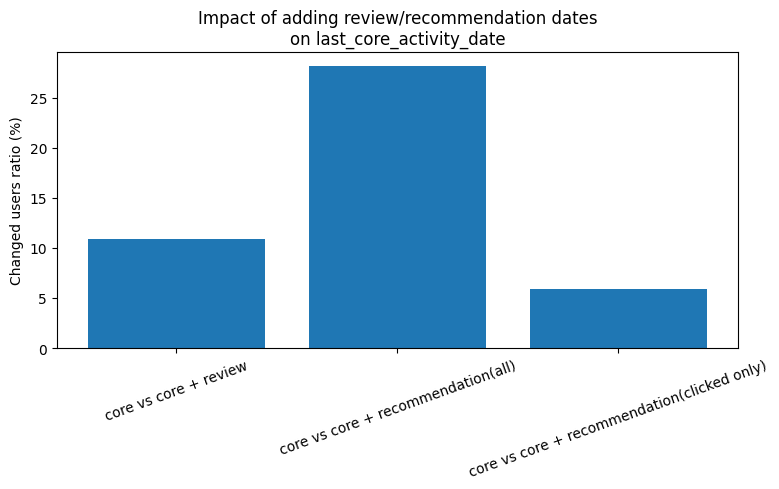

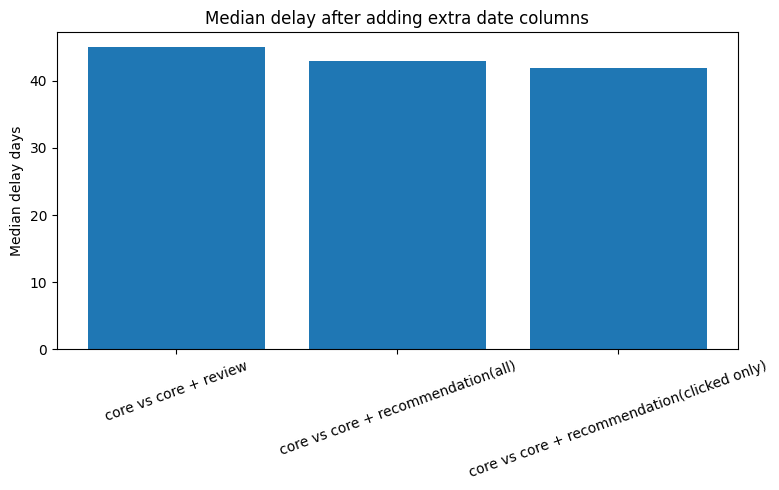

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 0. 날짜형 변환
# -------------------------------------------------
watch_tmp = watch[['user_id', 'watch_date']].copy()
search_tmp = search_logs[['user_id', 'search_date']].copy()
review_tmp = reviews[['user_id', 'review_date']].copy()
rec_tmp = rec_logs[['user_id', 'recommendation_date', 'was_clicked']].copy()

watch_tmp['watch_date'] = pd.to_datetime(watch_tmp['watch_date'], errors='coerce')
search_tmp['search_date'] = pd.to_datetime(search_tmp['search_date'], errors='coerce')
review_tmp['review_date'] = pd.to_datetime(review_tmp['review_date'], errors='coerce')
rec_tmp['recommendation_date'] = pd.to_datetime(rec_tmp['recommendation_date'], errors='coerce')

# recommendation 클릭 여부 0/1 변환
rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
    True: 1, False: 0,
    'True': 1, 'False': 0,
    'true': 1, 'false': 0,
    1: 1, 0: 0
})
rec_tmp['was_clicked_num'] = pd.to_numeric(rec_tmp['was_clicked_num'], errors='coerce')


# -------------------------------------------------
# 1. user별 마지막 날짜 map 만들기
# -------------------------------------------------
last_watch_date_map = watch_tmp.groupby('user_id')['watch_date'].max().to_dict()
last_search_date_map = search_tmp.groupby('user_id')['search_date'].max().to_dict()
last_review_date_map = review_tmp.groupby('user_id')['review_date'].max().to_dict()
last_recommendation_date_map = rec_tmp.groupby('user_id')['recommendation_date'].max().to_dict()

# 클릭한 recommendation만 따로
rec_clicked_tmp = rec_tmp[rec_tmp['was_clicked_num'] == 1].copy()
last_recommendation_click_date_map = (
    rec_clicked_tmp.groupby('user_id')['recommendation_date'].max().to_dict()
)


# -------------------------------------------------
# 2. 비교용 user-level 데이터프레임 만들기
# user는 기본 user 테이블
# -------------------------------------------------
compare_df = user[['user_id']].copy()

compare_df['last_watch_date'] = compare_df['user_id'].map(last_watch_date_map)
compare_df['last_search_date'] = compare_df['user_id'].map(last_search_date_map)
compare_df['last_review_date'] = compare_df['user_id'].map(last_review_date_map)
compare_df['last_recommendation_date'] = compare_df['user_id'].map(last_recommendation_date_map)
compare_df['last_recommendation_click_date'] = compare_df['user_id'].map(last_recommendation_click_date_map)

date_cols = [
    'last_watch_date',
    'last_search_date',
    'last_review_date',
    'last_recommendation_date',
    'last_recommendation_click_date'
]

for col in date_cols:
    compare_df[col] = pd.to_datetime(compare_df[col], errors='coerce')


# -------------------------------------------------
# 3. 핵심 기준 날짜 만들기
# "사실상 콘텐츠 소비가 끊긴 날"의 core 기준
# = watch + search
# -------------------------------------------------
compare_df['last_core_activity_date'] = compare_df[['last_watch_date', 'last_search_date']].max(axis=1)

# review 포함
compare_df['last_core_plus_review_date'] = compare_df[
    ['last_watch_date', 'last_search_date', 'last_review_date']
].max(axis=1)

# recommendation 전체 포함
compare_df['last_core_plus_recommendation_date'] = compare_df[
    ['last_watch_date', 'last_search_date', 'last_recommendation_date']
].max(axis=1)

# recommendation 클릭만 포함
compare_df['last_core_plus_recommendation_click_date'] = compare_df[
    ['last_watch_date', 'last_search_date', 'last_recommendation_click_date']
].max(axis=1)


# -------------------------------------------------
# 4. 영향도 비교 함수
# -------------------------------------------------
def summarize_impact(df, base_col, compare_col, label):
    delta_days = (df[compare_col] - df[base_col]).dt.days

    changed_mask = delta_days.notna() & (delta_days != 0)
    delayed_mask = delta_days > 0

    result = {
        'comparison': label,
        'total_users': len(df),
        'changed_users': int(changed_mask.sum()),
        'changed_ratio_%': round(changed_mask.mean() * 100, 2),
        'delayed_users': int(delayed_mask.sum()),
        'delayed_ratio_%': round(delayed_mask.mean() * 100, 2),
        'median_delay_days': int(delta_days[delayed_mask].median()) if delayed_mask.sum() > 0 else 0,
        'mean_delay_days': round(delta_days[delayed_mask].mean(), 2) if delayed_mask.sum() > 0 else 0,
        'p75_delay_days': int(delta_days[delayed_mask].quantile(0.75)) if delayed_mask.sum() > 0 else 0,
        'p90_delay_days': int(delta_days[delayed_mask].quantile(0.90)) if delayed_mask.sum() > 0 else 0,
        'max_delay_days': int(delta_days[delayed_mask].max()) if delayed_mask.sum() > 0 else 0,
    }
    return result


# -------------------------------------------------
# 5. review / recommendation 영향도 요약
# -------------------------------------------------
summary_list = []

summary_list.append(
    summarize_impact(
        compare_df,
        'last_core_activity_date',
        'last_core_plus_review_date',
        'core vs core + review'
    )
)

summary_list.append(
    summarize_impact(
        compare_df,
        'last_core_activity_date',
        'last_core_plus_recommendation_date',
        'core vs core + recommendation(all)'
    )
)

summary_list.append(
    summarize_impact(
        compare_df,
        'last_core_activity_date',
        'last_core_plus_recommendation_click_date',
        'core vs core + recommendation(clicked only)'
    )
)

summary_df = pd.DataFrame(summary_list)
print(summary_df)


# -------------------------------------------------
# 6. 커버리지 확인
# 각 날짜 컬럼이 실제로 얼마나 있는지
# -------------------------------------------------
coverage_df = pd.DataFrame({
    'column': [
        'last_watch_date',
        'last_search_date',
        'last_review_date',
        'last_recommendation_date',
        'last_recommendation_click_date',
        'last_core_activity_date'
    ],
    'non_null_count': [
        compare_df['last_watch_date'].notna().sum(),
        compare_df['last_search_date'].notna().sum(),
        compare_df['last_review_date'].notna().sum(),
        compare_df['last_recommendation_date'].notna().sum(),
        compare_df['last_recommendation_click_date'].notna().sum(),
        compare_df['last_core_activity_date'].notna().sum(),
    ]
})

coverage_df['non_null_ratio_%'] = round(coverage_df['non_null_count'] / len(compare_df) * 100, 2)
print(coverage_df)


# -------------------------------------------------
# 7. 발표용 그래프 1: 마지막 활동일이 바뀌는 유저 비율
# -------------------------------------------------
plot_df = summary_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df['comparison'], plot_df['changed_ratio_%'])
plt.ylabel('Changed users ratio (%)')
plt.title('Impact of adding review/recommendation dates\non last_core_activity_date')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 8. 발표용 그래프 2: 바뀐 유저들 기준 지연 일수 중앙값
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df['comparison'], plot_df['median_delay_days'])
plt.ylabel('Median delay days')
plt.title('Median delay after adding extra date columns')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


=== Non-churn users return gap summary ===
count: 97012
mean: 53.91
median: 38.00
p75: 75.00
p90: 124.00
p95: 161.00
p99: 245.00
max: 537

=== Gap summary table ===
   metric     value
0   count  97012.00
1    mean     53.91
2  median     38.00
3     p75     75.00
4     p90    124.00
5     p95    161.00
6     p99    245.00
7     max    537.00


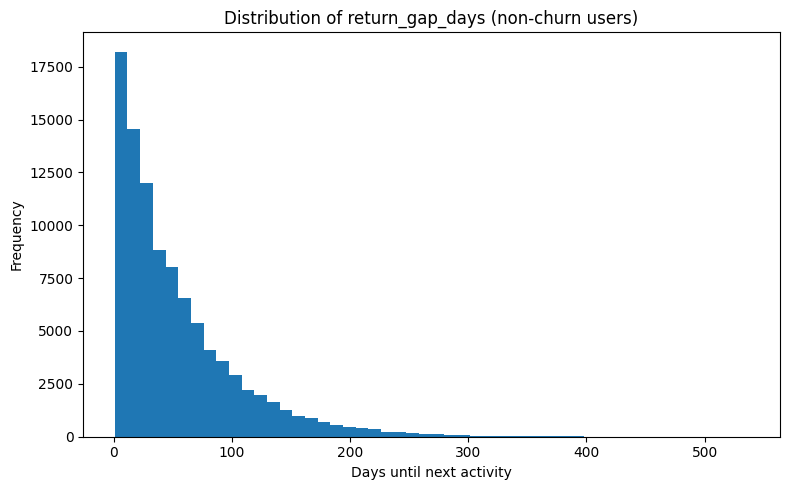

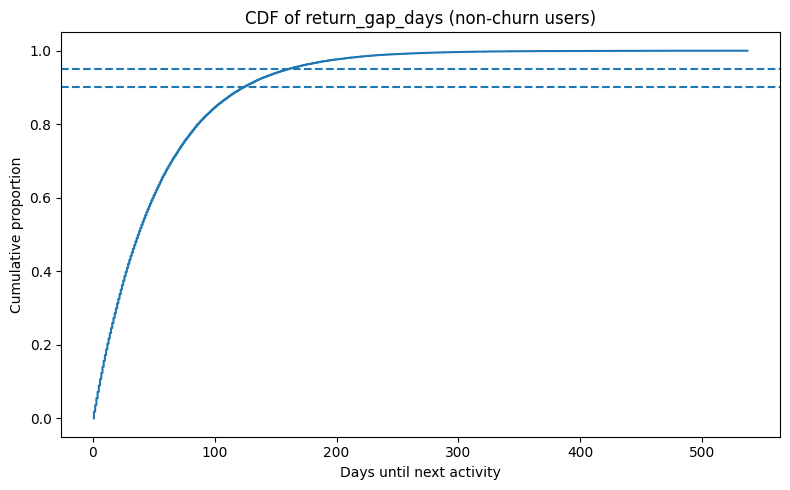

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 0. non-churn 유저 정의
# -------------------------------------------------
non_churn_user_ids = user.loc[user['is_active'] == True, 'user_id'].unique()

# -------------------------------------------------
# 1. activity 로그 만들기
# 기준: watch_date + search_date
# 같은 날 여러 활동은 1일 1활동으로 처리
# -------------------------------------------------
watch_activity = watch[['user_id', 'watch_date']].copy()
watch_activity = watch_activity.rename(columns={'watch_date': 'activity_date'})
watch_activity['activity_date'] = pd.to_datetime(watch_activity['activity_date'], errors='coerce')

search_activity = search_logs[['user_id', 'search_date']].copy()
search_activity = search_activity.rename(columns={'search_date': 'activity_date'})
search_activity['activity_date'] = pd.to_datetime(search_activity['activity_date'], errors='coerce')

activity_log = pd.concat([watch_activity, search_activity], ignore_index=True)

# non-churn 유저만 남기기
activity_log = activity_log[activity_log['user_id'].isin(non_churn_user_ids)].copy()

# 날짜 없는 행 제거
activity_log = activity_log.dropna(subset=['activity_date'])

# 날짜만 남기기 (시간 제거)
activity_log['activity_date'] = activity_log['activity_date'].dt.normalize()

# 같은 유저가 같은 날 여러 번 활동한 경우 1번으로 처리
activity_log = activity_log.drop_duplicates(subset=['user_id', 'activity_date'])

# -------------------------------------------------
# 2. 유저별 활동일 정렬 후 다음 활동일까지 gap 계산
# -------------------------------------------------
activity_log = activity_log.sort_values(['user_id', 'activity_date']).copy()

activity_log['next_activity_date'] = activity_log.groupby('user_id')['activity_date'].shift(-1)

activity_log['return_gap_days'] = (
    activity_log['next_activity_date'] - activity_log['activity_date']
).dt.days

# 마지막 활동은 다음 활동이 없으므로 제외
gap_df = activity_log.dropna(subset=['return_gap_days']).copy()

# 혹시 이상치/음수 방지
gap_df = gap_df[gap_df['return_gap_days'] >= 0].copy()

# 정수형
gap_df['return_gap_days'] = gap_df['return_gap_days'].astype(int)

# -------------------------------------------------
# 3. 요약 통계
# -------------------------------------------------
gap_summary = {
    'count': len(gap_df),
    'mean': gap_df['return_gap_days'].mean(),
    'median': gap_df['return_gap_days'].median(),
    'p75': gap_df['return_gap_days'].quantile(0.75),
    'p90': gap_df['return_gap_days'].quantile(0.90),
    'p95': gap_df['return_gap_days'].quantile(0.95),
    'p99': gap_df['return_gap_days'].quantile(0.99),
    'max': gap_df['return_gap_days'].max()
}

print("=== Non-churn users return gap summary ===")
for k, v in gap_summary.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

# -------------------------------------------------
# 4. 발표용 표
# -------------------------------------------------
gap_summary_df = pd.DataFrame({
    'metric': ['count', 'mean', 'median', 'p75', 'p90', 'p95', 'p99', 'max'],
    'value': [
        len(gap_df),
        round(gap_df['return_gap_days'].mean(), 2),
        round(gap_df['return_gap_days'].median(), 2),
        round(gap_df['return_gap_days'].quantile(0.75), 2),
        round(gap_df['return_gap_days'].quantile(0.90), 2),
        round(gap_df['return_gap_days'].quantile(0.95), 2),
        round(gap_df['return_gap_days'].quantile(0.99), 2),
        gap_df['return_gap_days'].max()
    ]
})

print("\n=== Gap summary table ===")
print(gap_summary_df)

# -------------------------------------------------
# 5. 히스토그램
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(gap_df['return_gap_days'], bins=50)
plt.title('Distribution of return_gap_days (non-churn users)')
plt.xlabel('Days until next activity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 6. 누적분포(CDF) 그래프
# 발표용으로 threshold 설명할 때 좋음
# -------------------------------------------------
sorted_gaps = np.sort(gap_df['return_gap_days'].values)
cdf = np.arange(1, len(sorted_gaps) + 1) / len(sorted_gaps)

plt.figure(figsize=(8, 5))
plt.plot(sorted_gaps, cdf)
plt.axhline(0.90, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.title('CDF of return_gap_days (non-churn users)')
plt.xlabel('Days until next activity')
plt.ylabel('Cumulative proportion')
plt.tight_layout()
plt.show()

In [5]:
from something import NetflixFeatureBuilder

builder = NetflixFeatureBuilder(
    user=user,
    watch=watch,
    reviews=reviews,
    rec_logs=rec_logs,
    search_logs=search_logs,
    movies=movies
)

print(hasattr(builder, 'new_user'))  # True 나와야 정상

True


In [6]:
builder.add_last_activity_date()
new_user = builder.get_data()
new_user.head()

c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:364: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({


,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,monthly_spend,primary_device,household_size,created_at,last_watch_date,last_search_date,last_review_date,last_recommendation_click_date,last_activity_date,last_core_activity_date
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,36.06,Laptop,1.0,2023-04-01 14:40:50.540242,2025-10-30,2024-12-29,2024-01-09,NaT,2025-10-30,2025-10-30
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,14.59,Desktop,2.0,2024-10-10 15:39:11.030515,2025-11-28,2025-12-08,2025-09-12,NaT,2025-12-08,2025-12-08
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,11.71,Desktop,3.0,2024-06-29 14:27:49.560875,2025-06-24,NaT,2024-04-17,2025-04-13,2025-06-24,2025-06-24
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,28.56,Laptop,2.0,2023-04-11 01:01:59.614841,2025-12-29,2025-12-29,2025-03-12,NaT,2025-12-29,2025-12-29
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,9.54,Desktop,6.0,2025-04-12 19:59:30.137806,2025-09-19,2025-09-29,2025-09-26,NaT,2025-09-29,2025-09-29


In [7]:
builder.add_estimated_churn_date_p50()
builder.add_final_estimated_churn_date()

new_user = builder.get_data()
new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,created_at,last_watch_date,last_search_date,last_review_date,last_recommendation_click_date,last_activity_date,last_core_activity_date,estimated_churn_date_p50,is_p50_estimate_valid,final_estimated_churn_date
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,2023-04-01 14:40:50.540242,2025-10-30,2024-12-29,2024-01-09,NaT,2025-10-30,2025-10-30,2025-12-07,True,NaT
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,2024-10-10 15:39:11.030515,2025-11-28,2025-12-08,2025-09-12,NaT,2025-12-08,2025-12-08,2026-01-15,True,NaT
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,2024-06-29 14:27:49.560875,2025-06-24,NaT,2024-04-17,2025-04-13,2025-06-24,2025-06-24,2025-08-01,True,2025-08-01
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,2023-04-11 01:01:59.614841,2025-12-29,2025-12-29,2025-03-12,NaT,2025-12-29,2025-12-29,2026-02-05,True,NaT
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,2025-04-12 19:59:30.137806,2025-09-19,2025-09-29,2025-09-26,NaT,2025-09-29,2025-09-29,2025-11-06,True,NaT


In [8]:
OBS_END_DATE = pd.to_datetime('2025-12-31')

new_user['final_estimated_churn_date'] = pd.to_datetime(
    new_user['final_estimated_churn_date'],
    errors='coerce'
)

new_user.loc[
    new_user['final_estimated_churn_date'] > OBS_END_DATE,
    'final_estimated_churn_date'
] = OBS_END_DATE

# 보기 좋게 date만 남기기
new_user['final_estimated_churn_date'] = new_user['final_estimated_churn_date'].dt.date

In [9]:
import pandas as pd

# -------------------------------------------------
# final_estimated_churn_date를 날짜형으로 변환
# -------------------------------------------------
new_user['final_estimated_churn_date'] = pd.to_datetime(
    new_user['final_estimated_churn_date'],
    errors='coerce'
)

# -------------------------------------------------
# compare_group만 추가
# - Target: 2025-11
# - Base: 2025-08 ~ 2025-10
# - active 유저 / 다른 월은 None
# -------------------------------------------------
new_user['compare_group'] = None

# 날짜에서 월 문자열을 "임시로" 계산
estimated_month = new_user['final_estimated_churn_date'].dt.to_period('M').astype(str)

# 2025-11 churn 유저
new_user.loc[
    (new_user['is_active'] == False) &
    (estimated_month == '2025-11'),
    'compare_group'
] = 'Target (2025-11)'

# 2025-08 ~ 2025-10 churn 유저
new_user.loc[
    (new_user['is_active'] == False) &
    (estimated_month.isin(['2025-08', '2025-09', '2025-10'])),
    'compare_group'
] = 'Base (2025-08~10)'

new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,last_watch_date,last_search_date,last_review_date,last_recommendation_click_date,last_activity_date,last_core_activity_date,estimated_churn_date_p50,is_p50_estimate_valid,final_estimated_churn_date,compare_group
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,2025-10-30,2024-12-29,2024-01-09,NaT,2025-10-30,2025-10-30,2025-12-07,True,NaT,None
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,2025-11-28,2025-12-08,2025-09-12,NaT,2025-12-08,2025-12-08,2026-01-15,True,NaT,None
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,2025-06-24,NaT,2024-04-17,2025-04-13,2025-06-24,2025-06-24,2025-08-01,True,2025-08-01,Base (2025-08~10)
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,2025-12-29,2025-12-29,2025-03-12,NaT,2025-12-29,2025-12-29,2026-02-05,True,NaT,None
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,2025-09-19,2025-09-29,2025-09-26,NaT,2025-09-29,2025-09-29,2025-11-06,True,NaT,None


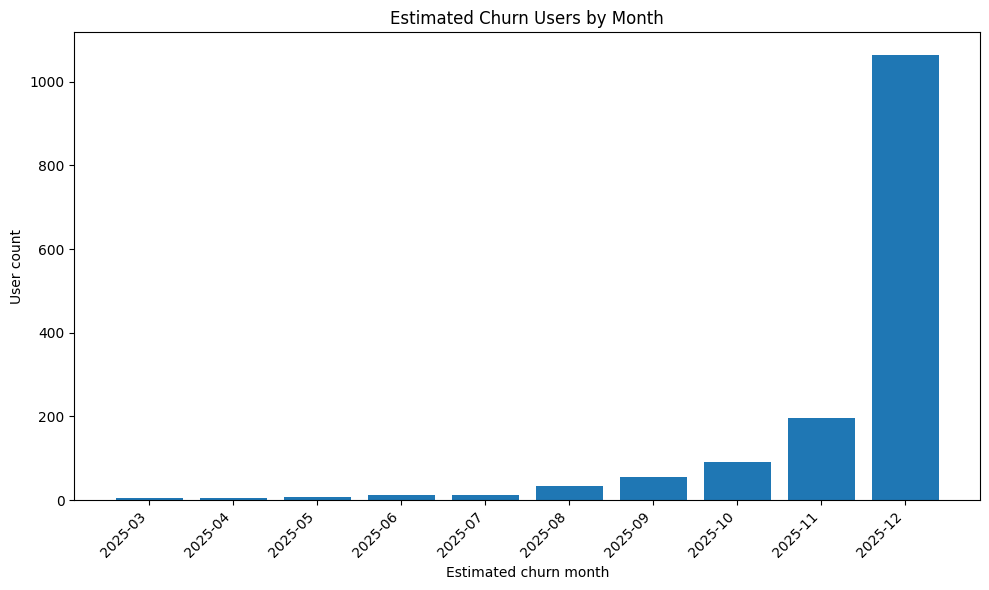

,estimated_churn_month,estimated_churn_user_count
0,2025-03,4
1,2025-04,4
2,2025-05,7
3,2025-06,12
4,2025-07,12
5,2025-08,33
6,2025-09,56
7,2025-10,92
8,2025-11,196
9,2025-12,1065


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# 1) new_user에서 필요한 컬럼만 임시로 가져오기
# ------------------------------------------
monthly_churn_source = new_user[['user_id', 'is_active', 'final_estimated_churn_date']].copy()

# ------------------------------------------
# 2) 날짜형으로 변환
# ------------------------------------------
monthly_churn_source['final_estimated_churn_date'] = pd.to_datetime(
    monthly_churn_source['final_estimated_churn_date'],
    errors='coerce'
)

# ------------------------------------------
# 3) churn 유저만 사용
#    - is_active == False
#    - estimated churn date가 있는 유저만 사용
# ------------------------------------------
monthly_churn_source = monthly_churn_source[
    (monthly_churn_source['is_active'] == False) &
    (monthly_churn_source['final_estimated_churn_date'].notna())
].copy()

# ------------------------------------------
# 4) 월 단위 문자열을 임시로 생성
#    예: 2025-11
#    new_user에는 저장하지 않음
# ------------------------------------------
monthly_churn_source['estimated_churn_month'] = (
    monthly_churn_source['final_estimated_churn_date']
    .dt.to_period('M')
    .astype(str)
)

# ------------------------------------------
# 5) 월별 estimated churn user 수 집계
# ------------------------------------------
monthly_churn_count = (
    monthly_churn_source
    .groupby('estimated_churn_month')['user_id']
    .count()
    .reset_index(name='estimated_churn_user_count')
    .sort_values('estimated_churn_month')
)

# ------------------------------------------
# 6) 그래프
# ------------------------------------------
plt.figure(figsize=(10, 6))
plt.bar(
    monthly_churn_count['estimated_churn_month'],
    monthly_churn_count['estimated_churn_user_count']
)

plt.xlabel('Estimated churn month')
plt.ylabel('User count')
plt.title('Estimated Churn Users by Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 표도 같이 확인
monthly_churn_count

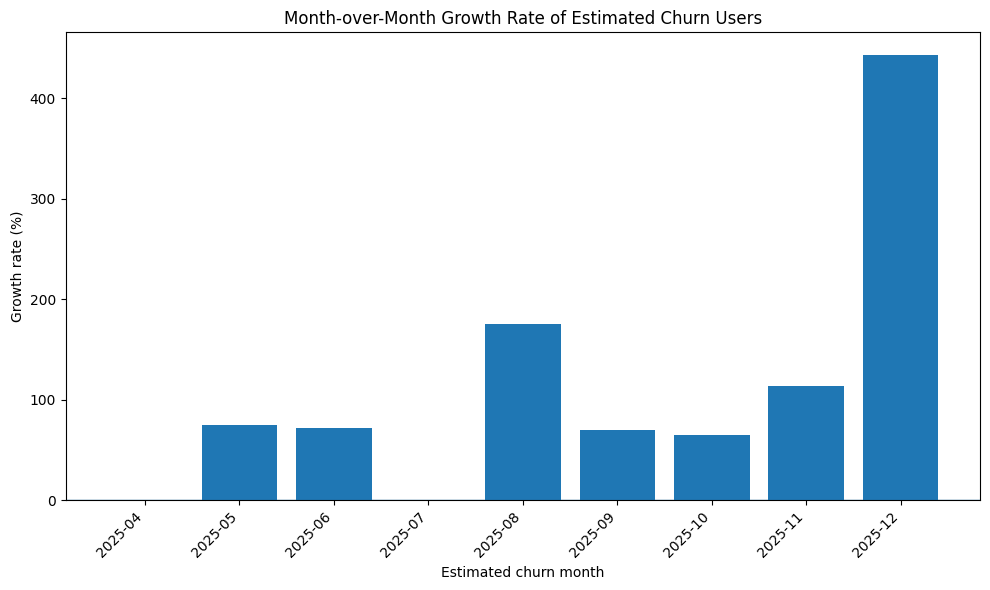

,estimated_churn_month,estimated_churn_user_count,growth_rate_pct
0,2025-03,4,NaN
1,2025-04,4,0.000000
2,2025-05,7,75.000000
3,2025-06,12,71.428571
4,2025-07,12,0.000000
5,2025-08,33,175.000000
6,2025-09,56,69.696970
7,2025-10,92,64.285714
8,2025-11,196,113.043478
9,2025-12,1065,443.367347


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------
# 1) 전월 대비 증가율(%) 계산
#    (현재월 - 이전월) / 이전월 * 100
# ------------------------------------------
monthly_churn_growth = monthly_churn_count.copy()

monthly_churn_growth['growth_rate_pct'] = (
    monthly_churn_growth['estimated_churn_user_count']
    .pct_change() * 100
)

# ------------------------------------------
# 2) 그래프
# ------------------------------------------
plt.figure(figsize=(10, 6))
plt.bar(
    monthly_churn_growth['estimated_churn_month'],
    monthly_churn_growth['growth_rate_pct']
)

plt.xlabel('Estimated churn month')
plt.ylabel('Growth rate (%)')
plt.title('Month-over-Month Growth Rate of Estimated Churn Users')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

monthly_churn_growth

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# [목적]
# new_user 전체에서
# "2025-11 estimated churn 유저"와
# "2025-09~10 estimated churn 유저"만 뽑아서
# 비교용 임시 데이터프레임(comparison_df)을 만든다.
#
# [주의]
# - new_user 자체는 수정하지 않음
# - comparison_df는 그래프 그리기 위한 임시 df
# -------------------------------------------------

# 1) 그래프 비교에 필요한 컬럼만 new_user에서 복사
#    user_id: 유저 수를 셀 때 필요
#    is_active: churn 유저만 고르기 위해 필요
#    final_estimated_churn_date: 이탈 추정 월 계산에 필요
#    subscription_plan / primary_device / country / age:
#    각각 비교 그래프에 필요한 기준 컬럼
comparison_df = new_user[
    ['user_id', 'is_active', 'final_estimated_churn_date',
     'subscription_plan', 'primary_device', 'country', 'age']
].copy()

# 2) final_estimated_churn_date를 datetime 형식으로 변환
#    문자열 상태면 month 추출이 불편하므로 먼저 날짜형으로 바꿔줌
comparison_df['final_estimated_churn_date'] = pd.to_datetime(
    comparison_df['final_estimated_churn_date'],
    errors='coerce'   # 날짜 변환이 안 되면 NaT 처리
)

# 3) churn 유저만 남김
#    여기서는 "왜 churn이 증가했는가?"를 볼 거라
#    active 유저는 비교 대상에서 제외
comparison_df = comparison_df[
    (comparison_df['is_active'] == False) &
    (comparison_df['final_estimated_churn_date'].notna())
].copy()

# 4) final_estimated_churn_date에서 월만 임시로 추출
#    예: 2025-11
#    new_user에는 저장하지 않고 comparison_df 안에서만 사용
estimated_month = (
    comparison_df['final_estimated_churn_date']
    .dt.to_period('M')
    .astype(str)
)

# 5) compare_group 컬럼 생성
#    우리가 비교하려는 두 그룹을 나눔
#    - Target: 2025-11 estimated churn 유저
#    - Base:   2025-09~10 estimated churn 유저
comparison_df['compare_group'] = None

# 6) 2025-11 유저는 Target 그룹으로 지정
comparison_df.loc[
    estimated_month == '2025-11',
    'compare_group'
] = 'Target (2025-11)'

# 7) 2025-09~10 유저는 Base 그룹으로 지정
comparison_df.loc[
    estimated_month.isin(['2025-09', '2025-10']),
    'compare_group'
] = 'Base (2025-09~10)'

# 8) Target / Base 둘 중 하나로 분류된 유저만 남김
#    다른 월(예: 8월, 12월)은 이번 비교에서 제외
comparison_df = comparison_df[
    comparison_df['compare_group'].notna()
].copy()

# 9) 확인
comparison_df.head()

,user_id,is_active,final_estimated_churn_date,subscription_plan,primary_device,country,age,compare_group
115,user_00116,False,2025-11-12,Standard,Tablet,USA,37.0,Target (2025-11)
139,user_00140,False,2025-09-20,Standard,Smart TV,USA,51.0,Base (2025-09~10)
145,user_00146,False,2025-11-03,Premium+,Gaming Console,USA,29.0,Target (2025-11)
182,user_00183,False,2025-11-29,Premium,Desktop,USA,22.0,Target (2025-11)
231,user_00232,False,2025-11-04,Premium,Gaming Console,USA,13.0,Target (2025-11)


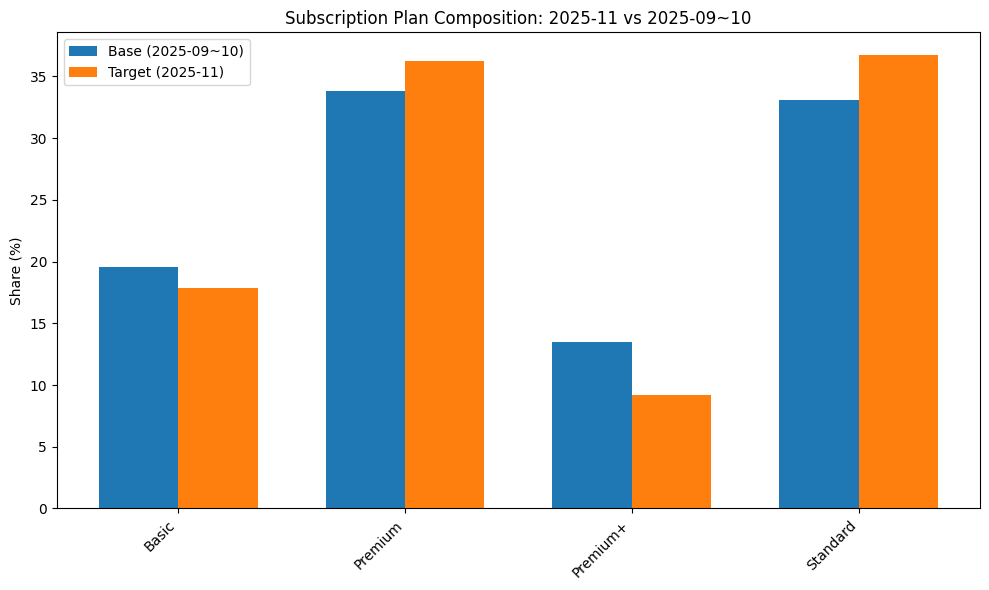

compare_group,Base (2025-09~10),Target (2025-11)
subscription_plan,,
Basic,0.195946,0.178571
Premium,0.337838,0.362245
Premium+,0.135135,0.091837
Standard,0.331081,0.367347


In [13]:
# -------------------------------------------------
# [목적]
# compare_group 별로 subscription_plan 구성비를 비교
#
# [해석]
# 예를 들어 Target(11월)에서 Premium 비중이 더 높다면,
# 11월 churn 증가가 Premium 사용자 쪽에서 상대적으로 더 많이 나타났다고 볼 수 있음
# -------------------------------------------------

# 1) compare_group + subscription_plan 조합별 유저 수 집계
#    예:
#    - Base (2025-09~10), Premium -> 몇 명?
#    - Target (2025-11), Basic -> 몇 명?
plan_plot = (
    comparison_df
    .groupby(['compare_group', 'subscription_plan'])['user_id']
    .count()
    .reset_index(name='user_count')
)

# 2) 각 그룹 내 비중(share) 계산
#    단순 count만 보면 그룹 크기가 달라서 비교가 어려움
#    그래서 각 compare_group 안에서 비율로 바꿈
plan_plot['share'] = (
    plan_plot['user_count']
    / plan_plot.groupby('compare_group')['user_count'].transform('sum')
)

# 3) 그래프 그리기 쉽게 pivot 형태로 변환
#    index   = subscription_plan
#    columns = compare_group
#    values  = share
#
#    결과 예:
#                     Base    Target
#      Basic          0.20    0.18
#      Premium        0.33    0.36
plan_pivot = plan_plot.pivot(
    index='subscription_plan',
    columns='compare_group',
    values='share'
).fillna(0)

# 4) 컬럼 순서 고정
#    항상 Base를 왼쪽, Target을 오른쪽에 두기 위함
plan_pivot = plan_pivot[['Base (2025-09~10)', 'Target (2025-11)']]

# 5) 막대 위치 계산
x = np.arange(len(plan_pivot))   # 구독 플랜 개수만큼 x축 좌표 생성
width = 0.35                     # 막대 너비

# 6) 그래프 생성
plt.figure(figsize=(10, 6))

# Base 그룹 막대
plt.bar(
    x - width/2,
    plan_pivot['Base (2025-09~10)'] * 100,   # 비율 -> %로 변환
    width=width,
    label='Base (2025-09~10)'
)

# Target 그룹 막대
plt.bar(
    x + width/2,
    plan_pivot['Target (2025-11)'] * 100,
    width=width,
    label='Target (2025-11)'
)

# 7) 축/제목/범례 설정
plt.xticks(x, plan_pivot.index.astype(str), rotation=45, ha='right')
plt.ylabel('Share (%)')
plt.title('Subscription Plan Composition: 2025-11 vs 2025-09~10')
plt.legend()
plt.tight_layout()
plt.show()

# 8) 표도 함께 보고 싶으면 출력
plan_pivot

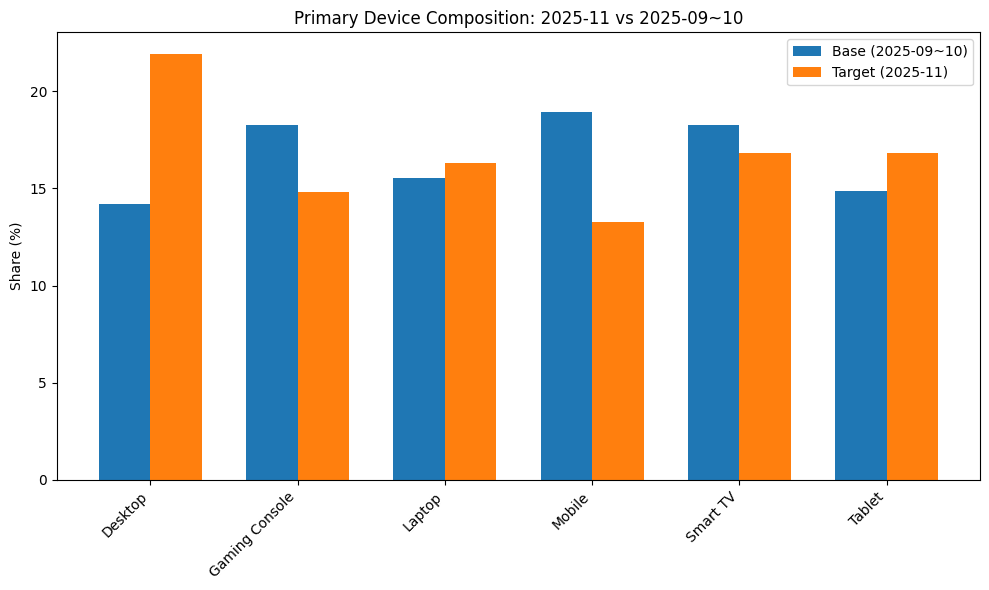

compare_group,Base (2025-09~10),Target (2025-11)
primary_device,,
Desktop,0.141892,0.219388
Gaming Console,0.182432,0.147959
Laptop,0.155405,0.163265
Mobile,0.189189,0.132653
Smart TV,0.182432,0.168367
Tablet,0.148649,0.168367


In [14]:
# -------------------------------------------------
# [목적]
# compare_group 별로 primary_device 구성비를 비교
#
# [해석]
# 예를 들어 Target에서 Desktop 비중이 높아졌다면,
# 11월 churn 증가는 Desktop 사용자 비중 증가와 연결될 수 있음
# -------------------------------------------------

# 1) compare_group + primary_device 조합별 유저 수 집계
device_plot = (
    comparison_df
    .groupby(['compare_group', 'primary_device'])['user_id']
    .count()
    .reset_index(name='user_count')
)

# 2) 각 그룹 내 비율 계산
device_plot['share'] = (
    device_plot['user_count']
    / device_plot.groupby('compare_group')['user_count'].transform('sum')
)

# 3) 그래프용 pivot 변환
device_pivot = device_plot.pivot(
    index='primary_device',
    columns='compare_group',
    values='share'
).fillna(0)

# 4) 컬럼 순서 고정
device_pivot = device_pivot[['Base (2025-09~10)', 'Target (2025-11)']]

# 5) 막대 위치 계산
x = np.arange(len(device_pivot))
width = 0.35

# 6) 그래프 생성
plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    device_pivot['Base (2025-09~10)'] * 100,
    width=width,
    label='Base (2025-09~10)'
)

plt.bar(
    x + width/2,
    device_pivot['Target (2025-11)'] * 100,
    width=width,
    label='Target (2025-11)'
)

# 7) 축/제목 설정
plt.xticks(x, device_pivot.index.astype(str), rotation=45, ha='right')
plt.ylabel('Share (%)')
plt.title('Primary Device Composition: 2025-11 vs 2025-09~10')
plt.legend()
plt.tight_layout()
plt.show()

# 8) 표 확인
device_pivot

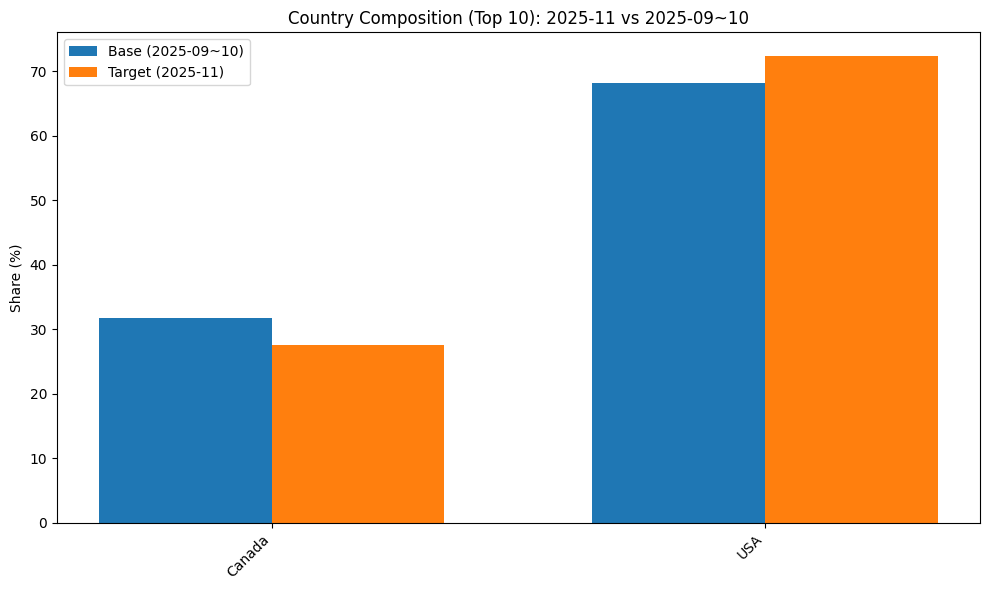

compare_group,Base (2025-09~10),Target (2025-11)
country,,
Canada,0.317568,0.27551
USA,0.682432,0.72449


In [15]:
# -------------------------------------------------
# [목적]
# compare_group 별로 country 구성비를 비교
#
# [주의]
# 국가는 종류가 많아서 전부 그리면 너무 복잡해질 수 있음
# 그래서 전체 유저 수 기준 상위 10개 국가만 표시
# -------------------------------------------------

# 1) compare_group + country 조합별 유저 수 집계
country_plot = (
    comparison_df
    .groupby(['compare_group', 'country'])['user_id']
    .count()
    .reset_index(name='user_count')
)

# 2) 전체 기준 상위 10개 국가 찾기
#    Base와 Target을 합쳐서 총합이 큰 국가 10개만 남김
top_countries = (
    country_plot
    .groupby('country')['user_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# 3) 상위 10개 국가만 남김
country_plot = country_plot[
    country_plot['country'].isin(top_countries)
].copy()

# 4) 각 그룹 내 비율 계산
country_plot['share'] = (
    country_plot['user_count']
    / country_plot.groupby('compare_group')['user_count'].transform('sum')
)

# 5) 그래프용 pivot
country_pivot = country_plot.pivot(
    index='country',
    columns='compare_group',
    values='share'
).fillna(0)

# 6) 컬럼 순서 고정
country_pivot = country_pivot[['Base (2025-09~10)', 'Target (2025-11)']]

# 7) 막대 위치 계산
x = np.arange(len(country_pivot))
width = 0.35

# 8) 그래프 생성
plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    country_pivot['Base (2025-09~10)'] * 100,
    width=width,
    label='Base (2025-09~10)'
)

plt.bar(
    x + width/2,
    country_pivot['Target (2025-11)'] * 100,
    width=width,
    label='Target (2025-11)'
)

# 9) 축/제목 설정
plt.xticks(x, country_pivot.index.astype(str), rotation=45, ha='right')
plt.ylabel('Share (%)')
plt.title('Country Composition (Top 10): 2025-11 vs 2025-09~10')
plt.legend()
plt.tight_layout()
plt.show()

# 10) 표 확인
country_pivot

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30536\3476953450.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['compare_group', 'age_group'])['user_id']


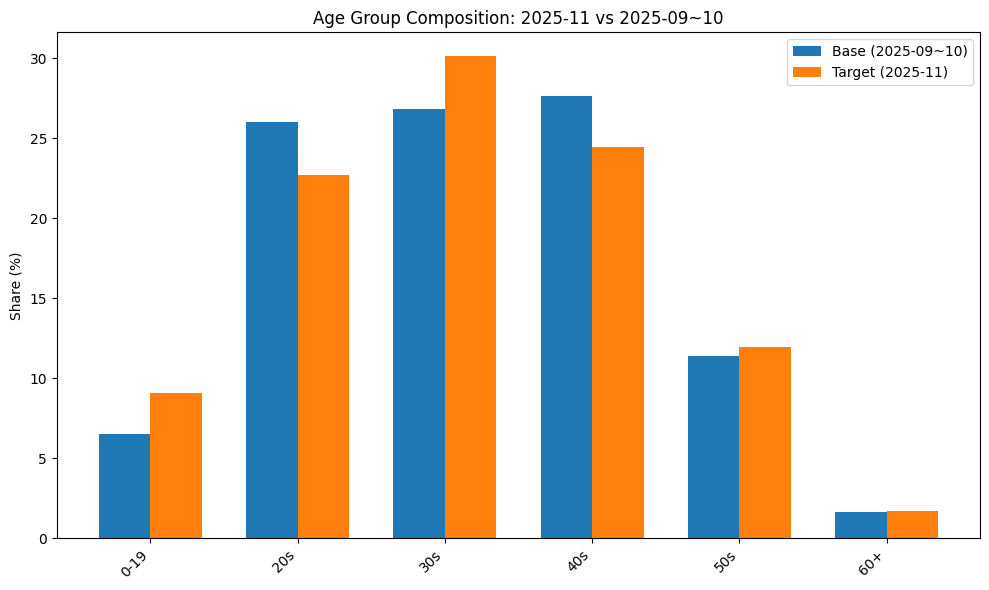

compare_group,Base (2025-09~10),Target (2025-11)
age_group,,
0-19,0.065041,0.090909
20s,0.260163,0.227273
30s,0.268293,0.301136
40s,0.276423,0.244318
50s,0.113821,0.119318
60+,0.016260,0.017045


In [16]:
# -------------------------------------------------
# [목적]
# compare_group 별로 age_group 구성비를 비교
#
# [주의]
# age는 숫자형이므로 바로 그래프에 쓰기보다
# 연령대 구간(age_group)으로 묶어서 비교하는 것이 더 해석하기 좋음
# -------------------------------------------------

# 1) comparison_df를 복사해서 연령대용 임시 df 생성
age_plot_df = comparison_df.copy()

# 2) age를 연령대 구간으로 변환
#    0~19 / 20s / 30s / 40s / 50s / 60+
age_plot_df['age_group'] = pd.cut(
    age_plot_df['age'],
    bins=[0, 19, 29, 39, 49, 59, 200],
    labels=['0-19', '20s', '30s', '40s', '50s', '60+'],
    right=True
)

# 3) compare_group + age_group 조합별 유저 수 집계
age_plot = (
    age_plot_df
    .groupby(['compare_group', 'age_group'])['user_id']
    .count()
    .reset_index(name='user_count')
)

# 4) 그룹 내 비율 계산
age_plot['share'] = (
    age_plot['user_count']
    / age_plot.groupby('compare_group')['user_count'].transform('sum')
)

# 5) 그래프용 pivot
age_pivot = age_plot.pivot(
    index='age_group',
    columns='compare_group',
    values='share'
).fillna(0)

# 6) 컬럼 순서 고정
age_pivot = age_pivot[['Base (2025-09~10)', 'Target (2025-11)']]

# 7) 막대 위치 계산
x = np.arange(len(age_pivot))
width = 0.35

# 8) 그래프 생성
plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    age_pivot['Base (2025-09~10)'] * 100,
    width=width,
    label='Base (2025-09~10)'
)

plt.bar(
    x + width/2,
    age_pivot['Target (2025-11)'] * 100,
    width=width,
    label='Target (2025-11)'
)

# 9) 축/제목 설정
plt.xticks(x, age_pivot.index.astype(str), rotation=45, ha='right')
plt.ylabel('Share (%)')
plt.title('Age Group Composition: 2025-11 vs 2025-09~10')
plt.legend()
plt.tight_layout()
plt.show()

# 10) 표 확인
age_pivot

In [17]:
# from something import NetflixFeatureBuilder

# builder = NetflixFeatureBuilder(
#     user=user,
#     watch=watch,
#     reviews=reviews,
#     rec_logs=rec_logs,
#     search_logs=search_logs,
#     movies=movies
# )

# print(hasattr(builder, 'new_user'))  # True 나와야 정상

In [18]:
builder.add_recommendation_click_rate()
builder.add_content_interactions()
builder.add_rating_given()
builder.add_completion_rate()
builder.add_watch_sessions_per_week()
builder.add_avg_watch_time_minutes()
builder.add_favorite_genre()


new_user = builder.get_data()
new_user.head()

c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({


,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,estimated_churn_date_p50,is_p50_estimate_valid,final_estimated_churn_date,recommendation_click_rate,content_interactions,rating_given,completion_rate,watch_sessions_per_week,avg_watch_time_minutes,favorite_genre
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,2025-12-07,True,NaT,0,2,4,50,1,44,War
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,2026-01-15,True,NaT,0,4,4,33,1,51,Horror
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,2025-08-01,True,2025-08-01,33,3,4,37,1,74,Animation
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,2026-02-05,True,NaT,0,3,3,28,1,82,Family
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,2025-11-06,True,NaT,0,4,3,22,1,40,Biography


C:\Users\Playdata\AppData\Local\Temp\ipykernel_30536\2752829613.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


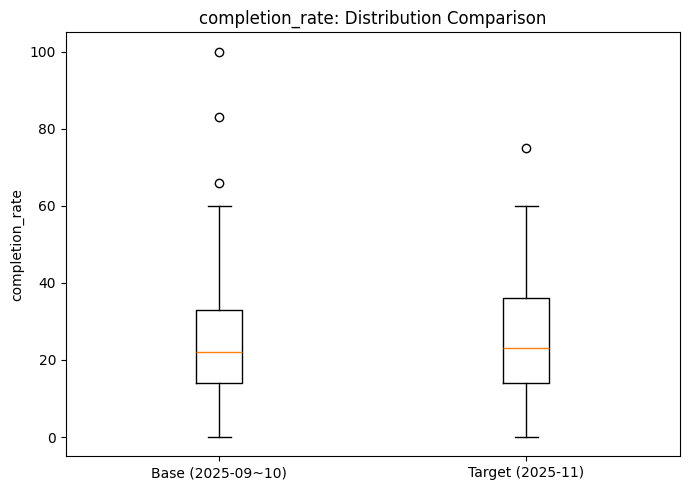

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30536\2752829613.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


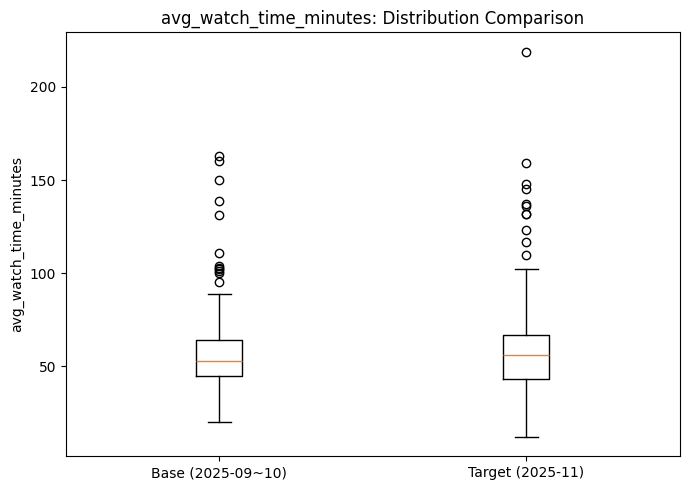

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30536\2752829613.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


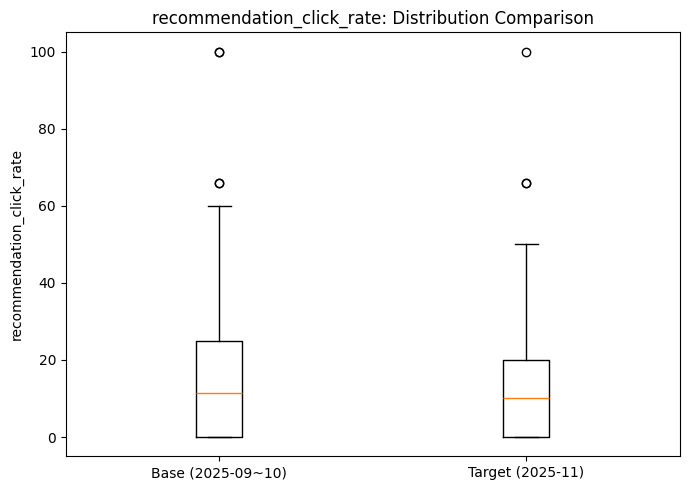

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30536\2752829613.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


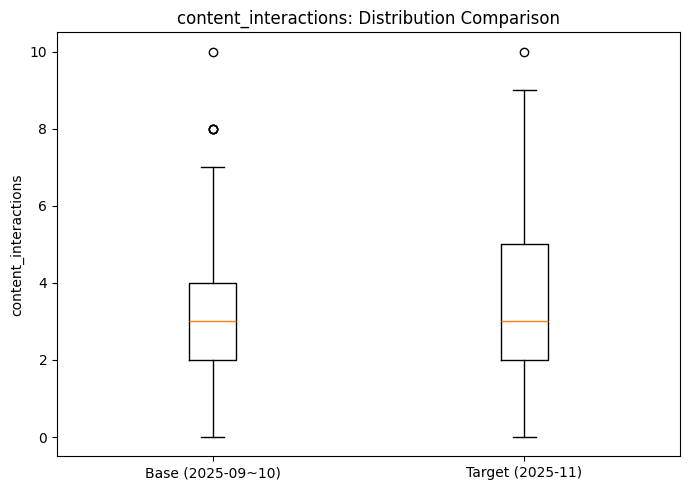

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30536\2752829613.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


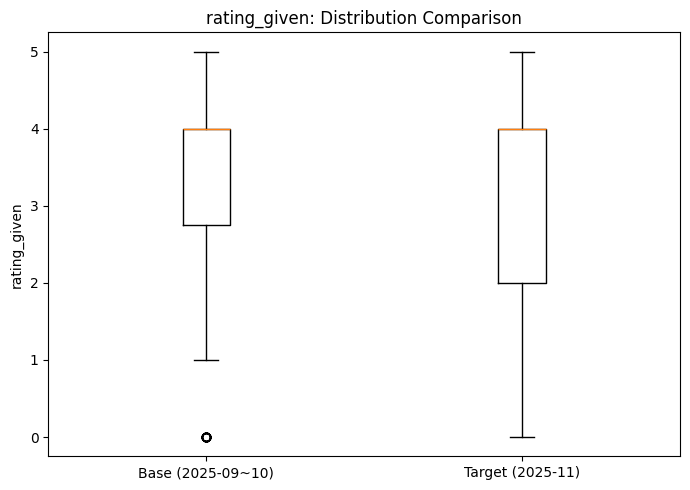

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# [목적]
# 2025-11 estimated churn 유저(Target)와
# 2025-09~10 estimated churn 유저(Base)를 비교해서
# 각 행동 지표의 "분포"를 boxplot으로 확인한다.
#
# [왜 이걸 보나?]
# 평균만 보면 일부 큰 값/작은 값 때문에 왜곡될 수 있다.
# boxplot은 중앙값, 퍼짐, 이상치를 같이 보여줘서
# "11월 churn 유저의 행동이 실제로 전체적으로 나빠졌는지"
# 더 잘 확인할 수 있다.
#
# [주의]
# - new_user 자체는 수정하지 않음
# - 그래프용 임시 df만 사용
# -------------------------------------------------

# 1) 비교에 필요한 컬럼만 복사
behavior_plot_df = new_user[
    [
        'user_id',
        'is_active',
        'final_estimated_churn_date',
        'completion_rate',
        'avg_watch_time_minutes',
        'recommendation_click_rate',
        'content_interactions',
        'rating_given'
    ]
].copy()

# 2) 날짜형으로 변환
behavior_plot_df['final_estimated_churn_date'] = pd.to_datetime(
    behavior_plot_df['final_estimated_churn_date'],
    errors='coerce'
)

# 3) churn 유저만 남기기
behavior_plot_df = behavior_plot_df[
    (behavior_plot_df['is_active'] == False) &
    (behavior_plot_df['final_estimated_churn_date'].notna())
].copy()

# 4) month를 임시로 계산
estimated_month = (
    behavior_plot_df['final_estimated_churn_date']
    .dt.to_period('M')
    .astype(str)
)

# 5) 비교 그룹 만들기
#    - 2025-11 -> Target
#    - 2025-09~10 -> Base
behavior_plot_df['compare_group'] = None

behavior_plot_df.loc[
    estimated_month == '2025-11',
    'compare_group'
] = 'Target (2025-11)'

behavior_plot_df.loc[
    estimated_month.isin(['2025-09', '2025-10']),
    'compare_group'
] = 'Base (2025-09~10)'

# 6) Base / Target만 남기기
behavior_plot_df = behavior_plot_df[
    behavior_plot_df['compare_group'].notna()
].copy()

# 7) 비교할 행동 컬럼 목록
behavior_columns = [
    'completion_rate',
    'avg_watch_time_minutes',
    'recommendation_click_rate',
    'content_interactions',
    'rating_given'
]

# 8) 컬럼별로 boxplot 생성
for col in behavior_columns:
    # boxplot용 데이터 준비
    base_values = behavior_plot_df.loc[
        behavior_plot_df['compare_group'] == 'Base (2025-09~10)', col
    ].dropna()

    target_values = behavior_plot_df.loc[
        behavior_plot_df['compare_group'] == 'Target (2025-11)', col
    ].dropna()

    # 그래프
    plt.figure(figsize=(7, 5))
    plt.boxplot(
        [base_values, target_values],
        labels=['Base (2025-09~10)', 'Target (2025-11)']
    )

    plt.ylabel(col)
    plt.title(f'{col}: Distribution Comparison')
    plt.tight_layout()
    plt.show()

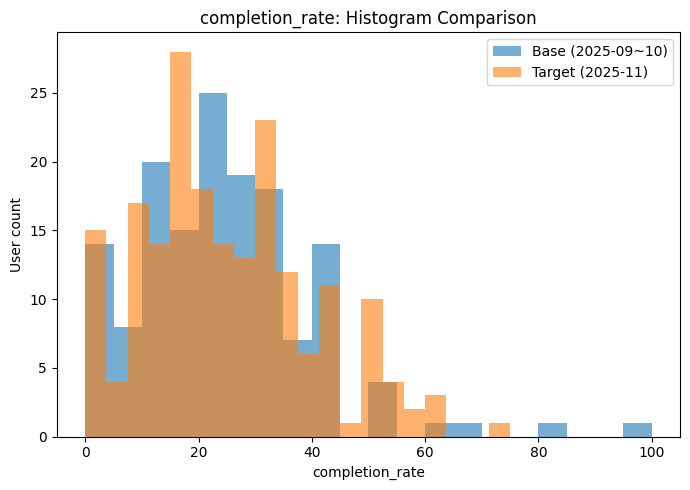

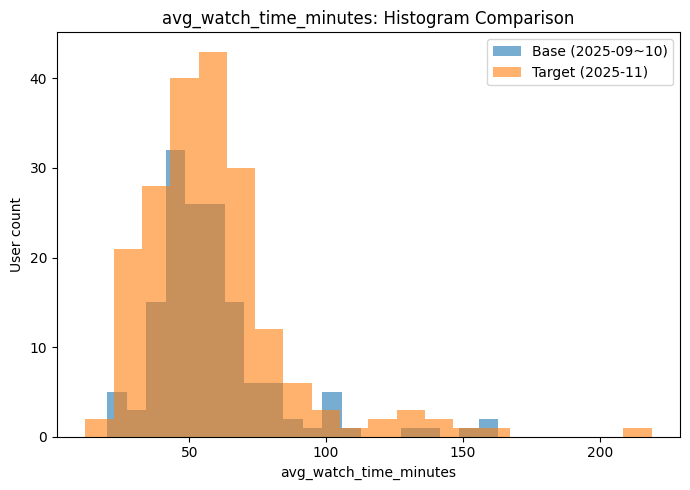

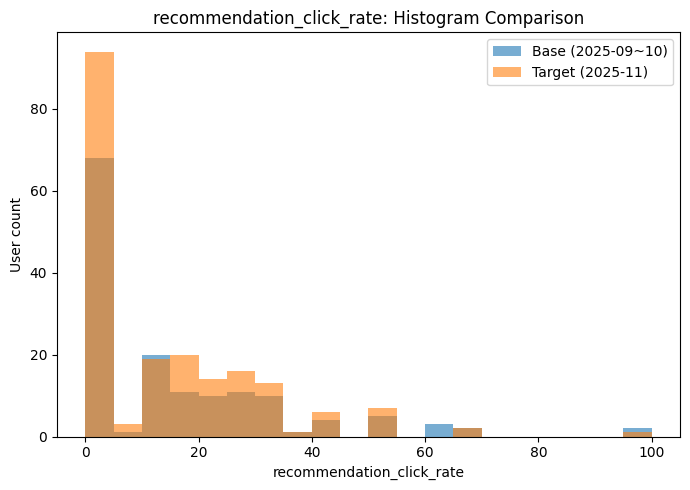

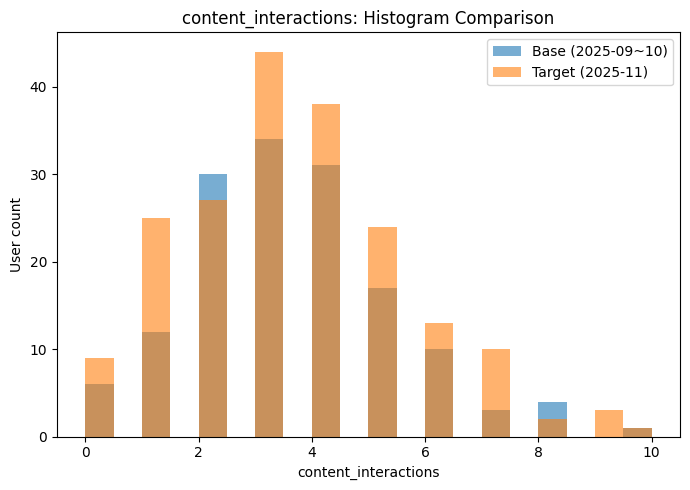

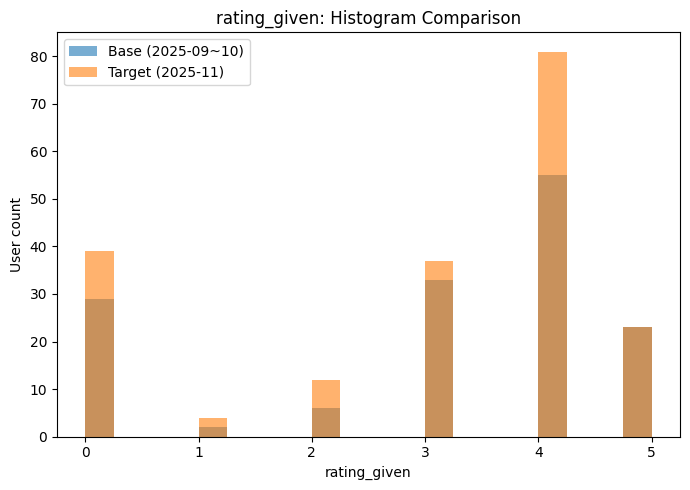

In [20]:
import matplotlib.pyplot as plt

# -------------------------------------------------
# [목적]
# 각 행동 지표에 대해
# Base vs Target 분포를 히스토그램으로 비교
# -------------------------------------------------

for col in behavior_columns:
    base_values = behavior_plot_df.loc[
        behavior_plot_df['compare_group'] == 'Base (2025-09~10)', col
    ].dropna()

    target_values = behavior_plot_df.loc[
        behavior_plot_df['compare_group'] == 'Target (2025-11)', col
    ].dropna()

    plt.figure(figsize=(7, 5))
    plt.hist(base_values, bins=20, alpha=0.6, label='Base (2025-09~10)')
    plt.hist(target_values, bins=20, alpha=0.6, label='Target (2025-11)')

    plt.xlabel(col)
    plt.ylabel('User count')
    plt.title(f'{col}: Histogram Comparison')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [21]:
builder.add_review_helpfulness_ratio()
builder.add_binge_day_ratio()
builder.add_avg_search_duration_seconds()

new_user = builder.get_data()
new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,recommendation_click_rate,content_interactions,rating_given,completion_rate,watch_sessions_per_week,avg_watch_time_minutes,favorite_genre,review_helpfulness_ratio,binge_day_ratio,avg_search_duration_seconds
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,0,2,4,50,1,44,War,0.000000,0.0,27.50
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,0,4,4,33,1,51,Horror,0.805556,0.0,18.10
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,33,3,4,37,1,74,Animation,0.000000,0.0,0.00
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,0,3,3,28,1,82,Family,1.000000,0.0,26.55
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,0,4,3,22,1,40,Biography,0.875000,0.0,37.70


C:\Users\Playdata\AppData\Local\Temp\ipykernel_30536\3602568837.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


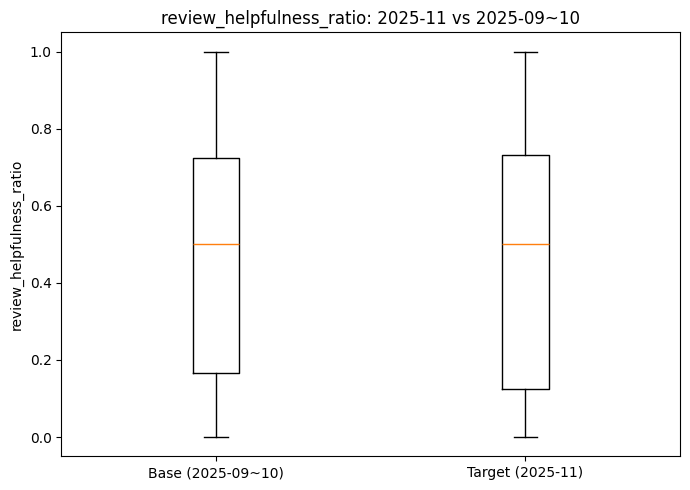

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30536\3602568837.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


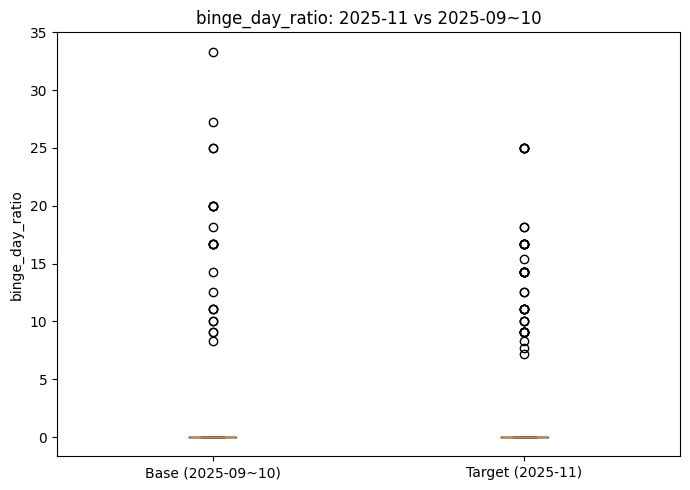

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30536\3602568837.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


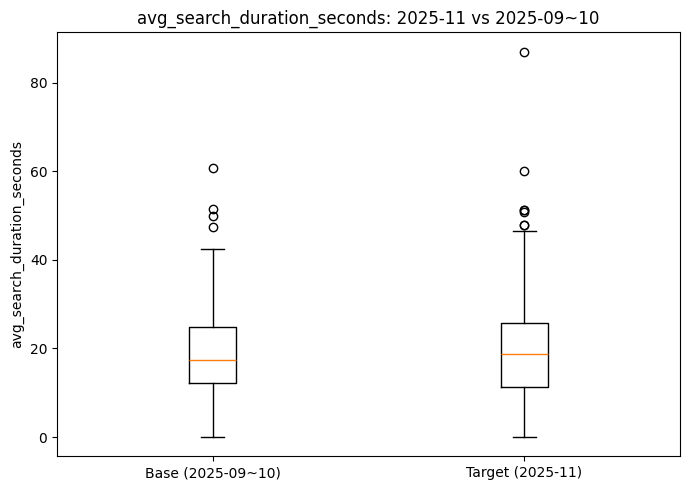

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# [목적]
# 새로 추가한 3개 컬럼에 대해
# 2025-09~10 estimated churn 유저(Base)와
# 2025-11 estimated churn 유저(Target)의 분포를 boxplot으로 비교
#
# [비교 컬럼]
# 1. review_helpfulness_ratio
# 2. binge_day_ratio
# 3. avg_search_duration_seconds
#
# [주의]
# - new_user 자체는 수정하지 않음
# - 그래프용 임시 데이터프레임만 사용
# -------------------------------------------------

# 1) 비교에 필요한 컬럼만 new_user에서 복사
boxplot_df = new_user[
    [
        'user_id',
        'is_active',
        'final_estimated_churn_date',
        'review_helpfulness_ratio',
        'binge_day_ratio',
        'avg_search_duration_seconds'
    ]
].copy()

# 2) final_estimated_churn_date를 날짜형으로 변환
#    문자열 상태일 수 있으므로 month 추출을 위해 datetime으로 변환
boxplot_df['final_estimated_churn_date'] = pd.to_datetime(
    boxplot_df['final_estimated_churn_date'],
    errors='coerce'
)

# 3) churn 유저만 남기기
#    이번 비교는 "estimated churn 유저"끼리의 비교이므로
#    is_active == False 이고 날짜가 있는 유저만 사용
boxplot_df = boxplot_df[
    (boxplot_df['is_active'] == False) &
    (boxplot_df['final_estimated_churn_date'].notna())
].copy()

# 4) final_estimated_churn_date에서 월 문자열을 임시 생성
#    예: '2025-11'
#    new_user에는 저장하지 않고 여기서만 사용
estimated_month = (
    boxplot_df['final_estimated_churn_date']
    .dt.to_period('M')
    .astype(str)
)

# 5) 비교 그룹 만들기
#    - 2025-11 -> Target
#    - 2025-09, 2025-10 -> Base
boxplot_df['compare_group'] = None

boxplot_df.loc[
    estimated_month == '2025-11',
    'compare_group'
] = 'Target (2025-11)'

boxplot_df.loc[
    estimated_month.isin(['2025-09', '2025-10']),
    'compare_group'
] = 'Base (2025-09~10)'

# 6) Base / Target으로 분류된 유저만 남기기
boxplot_df = boxplot_df[
    boxplot_df['compare_group'].notna()
].copy()

# 7) 비교할 컬럼 목록
comparison_columns = [
    'review_helpfulness_ratio',
    'binge_day_ratio',
    'avg_search_duration_seconds'
]

# 8) 컬럼 하나씩 boxplot 그리기
for col in comparison_columns:

    # Base 그룹 값 추출
    base_values = boxplot_df.loc[
        boxplot_df['compare_group'] == 'Base (2025-09~10)',
        col
    ].dropna()

    # Target 그룹 값 추출
    target_values = boxplot_df.loc[
        boxplot_df['compare_group'] == 'Target (2025-11)',
        col
    ].dropna()

    # 그래프 생성
    plt.figure(figsize=(7, 5))
    plt.boxplot(
        [base_values, target_values],
        labels=['Base (2025-09~10)', 'Target (2025-11)']
    )

    # 축/제목 설정
    plt.ylabel(col)
    plt.title(f'{col}: 2025-11 vs 2025-09~10')
    plt.tight_layout()
    plt.show()

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# [목적]
# 월별 estimated churn 유저 수와
# 월별 revenue-at-risk(monthly_spend 합)를 확인한다.
#
# [정의]
# - churn user count:
#   해당 월 estimated churn 유저 수
#
# - revenue at risk:
#   해당 월 estimated churn 유저들의 monthly_spend 합
#
# [주의]
# - new_user 자체는 수정하지 않음
# - 분석용 임시 df만 사용
# -------------------------------------------------

# 1) 필요한 컬럼만 임시로 복사
monthly_risk_df = new_user[
    ['user_id', 'is_active', 'final_estimated_churn_date', 'monthly_spend']
].copy()

# 2) 날짜형 / 숫자형 변환
monthly_risk_df['final_estimated_churn_date'] = pd.to_datetime(
    monthly_risk_df['final_estimated_churn_date'],
    errors='coerce'
)

monthly_risk_df['monthly_spend'] = pd.to_numeric(
    monthly_risk_df['monthly_spend'],
    errors='coerce'
)

# 3) churn 유저만 사용 + estimated churn date가 있는 유저만 사용
monthly_risk_df = monthly_risk_df[
    (monthly_risk_df['is_active'] == False) &
    (monthly_risk_df['final_estimated_churn_date'].notna())
].copy()

# 4) 월 문자열을 임시로 생성
#    예: 2025-11
monthly_risk_df['estimated_churn_month'] = (
    monthly_risk_df['final_estimated_churn_date']
    .dt.to_period('M')
    .astype(str)
)

# 5) 월별 집계
#    - churn_user_count: 유저 수
#    - monthly_spend_sum: 매출 위험 합계
#    - monthly_spend_mean: 해당 월 churn 유저 평균 spend
monthly_risk_summary = (
    monthly_risk_df
    .groupby('estimated_churn_month')
    .agg(
        churn_user_count=('user_id', 'count'),
        monthly_spend_sum=('monthly_spend', 'sum'),
        monthly_spend_mean=('monthly_spend', 'mean')
    )
    .reset_index()
    .sort_values('estimated_churn_month')
)

# 6) 집계표 확인
monthly_risk_summary

,estimated_churn_month,churn_user_count,monthly_spend_sum,monthly_spend_mean
0,2025-03,4,3.85,3.850000
1,2025-04,4,50.11,12.527500
2,2025-05,7,88.74,14.790000
3,2025-06,12,214.37,17.864167
4,2025-07,12,220.26,20.023636
5,2025-08,33,410.90,13.254839
6,2025-09,56,1683.00,33.660000
7,2025-10,92,2782.55,35.222152
8,2025-11,196,3996.82,22.454045
9,2025-12,353,7298.65,23.393109


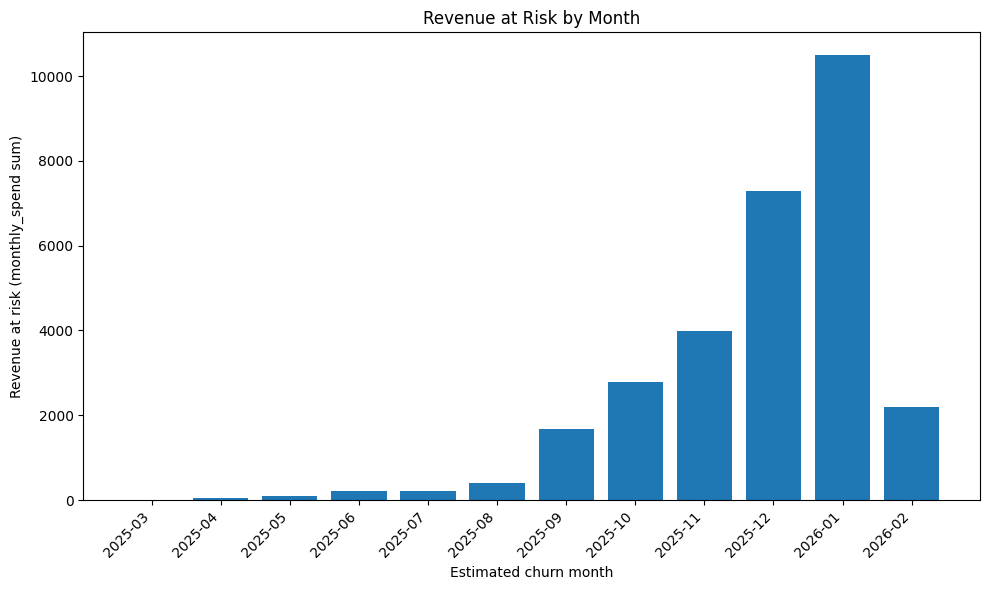

In [ ]:
# -------------------------------------------------
# 월별 revenue-at-risk 그래프
# = 월별 churn 유저 monthly_spend 합
# -------------------------------------------------

plt.figure(figsize=(10, 6))
plt.bar(
    monthly_risk_summary['estimated_churn_month'],
    monthly_risk_summary['monthly_spend_sum']
)

plt.xlabel('Estimated churn month')
plt.ylabel('Revenue at risk (monthly_spend sum)')
plt.title('Revenue at Risk by Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

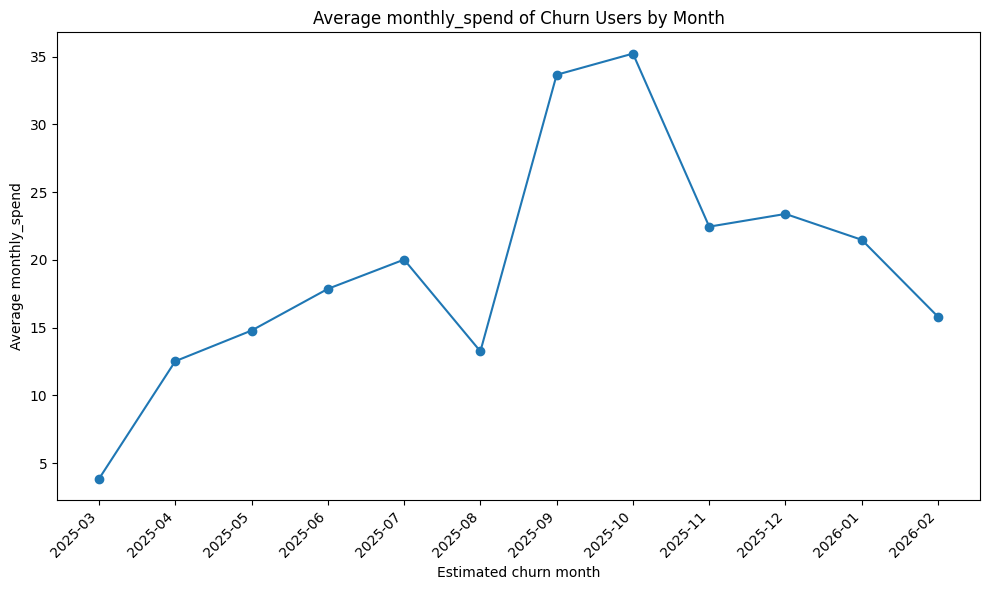

In [26]:
# -------------------------------------------------
# 월별 churn 유저 평균 monthly_spend 그래프
# -------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(
    monthly_risk_summary['estimated_churn_month'],
    monthly_risk_summary['monthly_spend_mean'],
    marker='o'
)

plt.xlabel('Estimated churn month')
plt.ylabel('Average monthly_spend')
plt.title('Average monthly_spend of Churn Users by Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# 2025-11 estimated churn 유저 중
# 상위 요금제 vs 하위 요금제 비교
# -------------------------------------------------

tier_df = new_user[
    [
        'user_id',
        'is_active',
        'final_estimated_churn_date',
        'subscription_plan',
        'recommendation_click_rate',
        'rating_given',
        'content_interactions'
    ]
].copy()

# 날짜형 변환
tier_df['final_estimated_churn_date'] = pd.to_datetime(
    tier_df['final_estimated_churn_date'],
    errors='coerce'
)

# 2025-11 churn 유저만 사용
estimated_month = tier_df['final_estimated_churn_date'].dt.to_period('M').astype(str)

tier_df = tier_df[
    (tier_df['is_active'] == False) &
    (estimated_month == '2025-11')
].copy()

# 상위/하위 요금제 그룹 만들기
tier_df['tier_group'] = None

tier_df.loc[
    tier_df['subscription_plan'].isin(['Premium', 'Premium+']),
    'tier_group'
] = 'High tier'

tier_df.loc[
    tier_df['subscription_plan'].isin(['Basic', 'Standard']),
    'tier_group'
] = 'Low tier'

# 필요한 행만 남기기
tier_df = tier_df[tier_df['tier_group'].notna()].copy()

# 확인
tier_df[['user_id', 'subscription_plan', 'tier_group']].head()

,user_id,subscription_plan,tier_group
115,user_00116,Standard,Low tier
145,user_00146,Premium+,High tier
182,user_00183,Premium,High tier
231,user_00232,Premium,High tier
273,user_00274,Standard,Low tier


In [34]:
tier_summary = (
    tier_df
    .groupby('tier_group')
    .agg(
        user_count=('user_id', 'count'),
        recommendation_click_rate_mean=('recommendation_click_rate', 'mean'),
        rating_given_mean=('rating_given', 'mean'),
        content_interactions_mean=('content_interactions', 'mean')
    )
    .reset_index()
)

tier_summary

,tier_group,user_count,recommendation_click_rate_mean,rating_given_mean,content_interactions_mean
0,High tier,89,12.157303,3.202247,3.629213
1,Low tier,107,13.738318,2.738318,3.373832


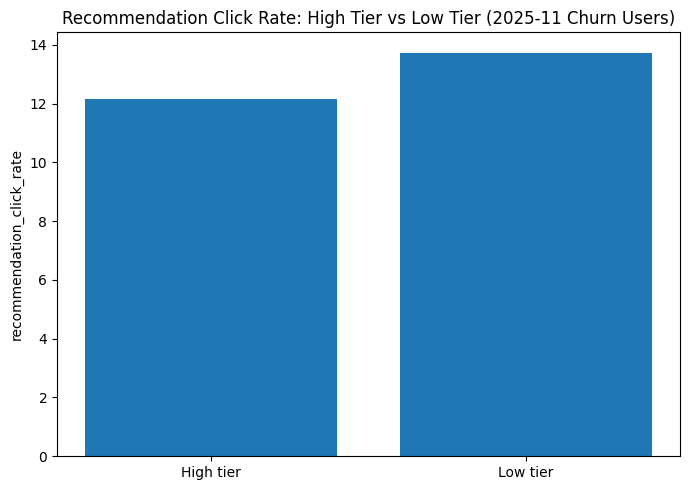

In [35]:
rec_plot = (
    tier_df.groupby('tier_group')['recommendation_click_rate']
    .mean()
    .reset_index(name='mean_value')
)

plt.figure(figsize=(7, 5))
plt.bar(rec_plot['tier_group'], rec_plot['mean_value'])
plt.ylabel('recommendation_click_rate')
plt.title('Recommendation Click Rate: High Tier vs Low Tier (2025-11 Churn Users)')
plt.tight_layout()
plt.show()

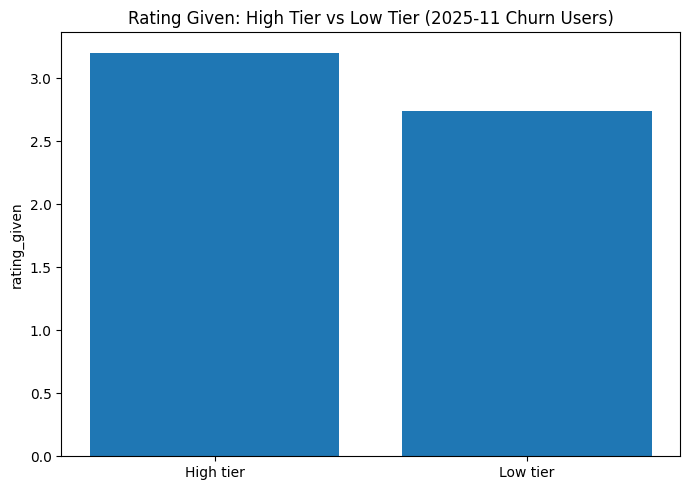

In [36]:
rating_plot = (
    tier_df.groupby('tier_group')['rating_given']
    .mean()
    .reset_index(name='mean_value')
)

plt.figure(figsize=(7, 5))
plt.bar(rating_plot['tier_group'], rating_plot['mean_value'])
plt.ylabel('rating_given')
plt.title('Rating Given: High Tier vs Low Tier (2025-11 Churn Users)')
plt.tight_layout()
plt.show()

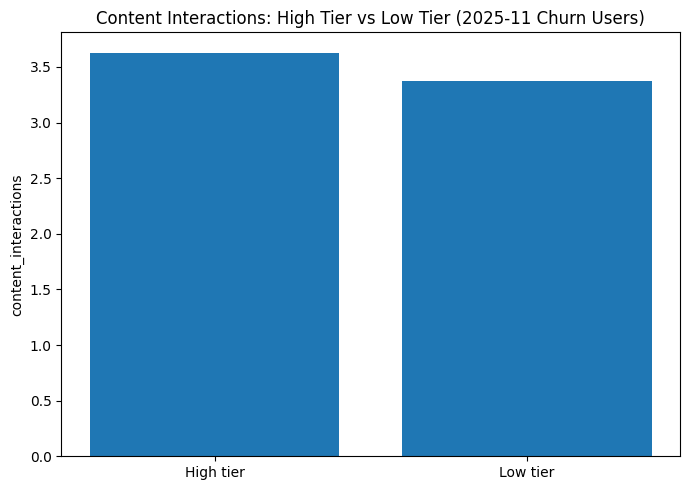

In [37]:
interaction_plot = (
    tier_df.groupby('tier_group')['content_interactions']
    .mean()
    .reset_index(name='mean_value')
)

plt.figure(figsize=(7, 5))
plt.bar(interaction_plot['tier_group'], interaction_plot['mean_value'])
plt.ylabel('content_interactions')
plt.title('Content Interactions: High Tier vs Low Tier (2025-11 Churn Users)')
plt.tight_layout()
plt.show()